<a href="https://colab.research.google.com/github/AksharaBasu/GenAI/blob/main/LLM1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Groq connected
✅ Graph compiled successfully


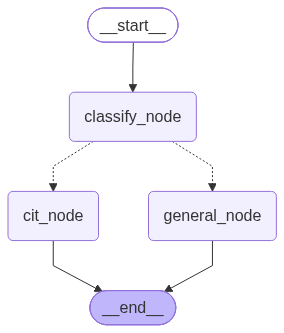

🔀 Route: CIT

QUESTION:
What departments are available at CIT Ponnampet?

ROUTE:
CIT

ANSWER:
The departments available at CIT Ponnampet are:

1. Computer Science and Engineering  
2. Electronics and Communication Engineering  
3. Mechanical Engineering  
4. Civil Engineering  
5. Artificial Intelligence and Machine Learning  
6. Artificial Intelligence and Data Science  
7. Computer Science and Engineering (Cyber Security)
🔀 Route: GENERAL

QUESTION:
Explain Python functions in simple words.

ROUTE:
GENERAL

ANSWER:
### What is a Python function?

Think of a function as a **mini‑program** that does one specific job.  
You write it once, give it a name, and then you can call it over and over again whenever you need that job done.

---

#### 1. Why use functions?

| Problem | Function helps |
|---------|----------------|
| Repeating the same code in many places | Put the code in one place and call it. |
| Making code easier to read | Each function has a clear purpose. |
| Changing a beh

In [ ]:
# ============================================================
# CIT PONNAMPET - LANGGRAPH DEMO
# STATE + NODES + ROUTE + GRAPH + LLM
# ============================================================

# Install required packages
%pip install -q -U langgraph groq


# ============================================================
# 1. IMPORTS
# ============================================================

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from groq import Groq
from google.colab import userdata


# ============================================================
# 2. GROQ API KEY
# ============================================================

GROQ_API_KEY = userdata.get("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError(
        "GROQ_API_KEY not found. "
        "Go to Colab Secrets and add GROQ_API_KEY."
    )

GROQ_API_KEY = GROQ_API_KEY.strip()

client = Groq(
    api_key=GROQ_API_KEY
)

MODEL = "openai/gpt-oss-20b"

print("✅ Groq connected")


# ============================================================
# 3. STATE
# ============================================================

class State(TypedDict, total=False):
    question: str
    route: str
    context: str
    answer: str


# ============================================================
# 4. CIT INFORMATION
# ============================================================

CIT_CONTEXT = """
Coorg Institute of Technology (CIT) is located in Ponnampet,
Kodagu, Karnataka.

CIT has engineering departments/programmes including:

1. Computer Science and Engineering
2. Electronics and Communication Engineering
3. Mechanical Engineering
4. Civil Engineering
5. Artificial Intelligence and Machine Learning
6. Artificial Intelligence and Data Science
7. Computer Science and Engineering (Cyber Security)

This information is used for demonstration of a
department information chatbot.
"""


# ============================================================
# 5. NODE 1 - CLASSIFY QUESTION
# ============================================================

def classify_node(state: State):

    question = state["question"]

    prompt = f"""
Classify the question into exactly one category.

CIT:
The question is about Coorg Institute of Technology,
CIT Ponnampet, its departments, courses, faculty,
admissions, campus, or college information.

GENERAL:
The question is not about CIT.

Question:
{question}

Reply with exactly one word:
CIT
or
GENERAL
"""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    route = response.choices[0].message.content.strip().upper()

    if route not in ["CIT", "GENERAL"]:
        route = "GENERAL"

    print("🔀 Route:", route)

    return {
        "route": route
    }


# ============================================================
# 6. ROUTE
# ============================================================

def route_question(state: State):

    if state["route"] == "CIT":
        return "cit_node"

    return "general_node"


# ============================================================
# 7. NODE 2 - CIT
# ============================================================

def cit_node(state: State):

    question = state["question"]

    prompt = f"""
You are a CIT Ponnampet information assistant.

Answer ONLY from the context below.

If the requested information is not available,
say exactly:

"I do not have enough information."

CIT CONTEXT:
{CIT_CONTEXT}

QUESTION:
{question}
"""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "system",
                "content": prompt
            },
            {
                "role": "user",
                "content": question
            }
        ],
        temperature=0
    )

    answer = response.choices[0].message.content

    return {
        "context": CIT_CONTEXT,
        "answer": answer
    }


# ============================================================
# 8. NODE 3 - GENERAL
# ============================================================

def general_node(state: State):

    question = state["question"]

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "system",
                "content": "You are a helpful general AI assistant."
            },
            {
                "role": "user",
                "content": question
            }
        ],
        temperature=0
    )

    answer = response.choices[0].message.content

    return {
        "answer": answer
    }


# ============================================================
# 9. BUILD GRAPH
# ============================================================

builder = StateGraph(State)

# Add nodes
builder.add_node(
    "classify_node",
    classify_node
)

builder.add_node(
    "cit_node",
    cit_node
)

builder.add_node(
    "general_node",
    general_node
)


# START → CLASSIFIER
builder.add_edge(
    START,
    "classify_node"
)


# CLASSIFIER → ROUTE
builder.add_conditional_edges(
    "classify_node",
    route_question,
    {
        "cit_node": "cit_node",
        "general_node": "general_node"
    }
)


# FINAL NODES → END
builder.add_edge(
    "cit_node",
    END
)

builder.add_edge(
    "general_node",
    END
)


# Compile
graph = builder.compile()

print("✅ Graph compiled successfully")


# ============================================================
# 10. DISPLAY GRAPH
# ============================================================

try:

    from IPython.display import Image, display

    display(
        Image(
            graph.get_graph().draw_mermaid_png()
        )
    )

except Exception as e:

    print("Graph image could not be displayed:", e)


# ============================================================
# 11. FUNCTION TO ASK QUESTION
# ============================================================

def ask_question(question):

    result = graph.invoke({
        "question": question
    })

    print("\n" + "=" * 60)
    print("QUESTION:")
    print(question)

    print("\nROUTE:")
    print(result.get("route", "Not returned"))

    print("\nANSWER:")
    print(result.get("answer", "No answer"))

    print("=" * 60)

    return result


# ============================================================
# 12. TEST CIT QUESTION
# ============================================================

ask_question(
    "What departments are available at CIT Ponnampet?"
)


# ============================================================
# 13. TEST GENERAL QUESTION
# ============================================================

ask_question(
    "Explain Python functions in simple words."
)


# ============================================================
# 14. INTERACTIVE CHAT
# ============================================================

print("\n🤖 CIT LANGGRAPH CHATBOT READY")
print("Type 'exit' to stop.")

while True:

    question = input("\nYou: ").strip()

    if question.lower() == "exit":
        print("Chatbot stopped.")
        break

    if not question:
        continue

    result = graph.invoke({
        "question": question
    })

    print("\nAI:")
    print(result.get("answer", "No answer"))

    print("\nRoute:", result.get("route", "N/A"))